# LDS Non-EV submodel — validation

Confirms that the fitted LDS captures Non-EV well *given ground-truth* Non-EV
observations — independent of the EV side. The smoother is run directly on
$x^{NonEV}_{1:D_n}$ (no EV-side coupling), and:

- For configured (home, day) pairs, plot smoothed $\hat z^{LDS,(n)}_d$ vs
  ground-truth $x^{NonEV,(n)}_d$ across timesteps $t \in 1..T$.
- Report per-home marginal $\log p(x^{NonEV,(n)}_{1:D_n})$ under the fitted LDS.

Notebook structure:
1. Imports + load fitted LDS + training data
2. Configure (home, day) pairs to plot — manual list, random N, or by-fit-quality
3. Per-(home,day) inference plots
4. Per-home marginal log p(x^NonEV) summary

## 1. Imports + data

In [64]:
import sys, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks' / 'utils'))

from data_utils import load_split
from models import graphical_model as gm
from models.graphical_model.non_ev_lds import LDSParams

In [65]:
# Load fitted LDS
lds_path = PROJECT_ROOT / 'models' / 'lds_params.pkl'
with open(lds_path, 'rb') as f:
    lds: LDSParams = pickle.load(f)
print(lds.summary())

LDSParams summary
----------------------------------------
  latent_dim L = 96, obs_dim M = 96
  A             shape=(96, 96)  (identity? True)
  C             shape=(96, 96)  (identity? True)
  mu_0          (min=+0.579, median=+0.824, max=+1.202)
  diag(Sigma_0) (min=0.1526, median=0.5210, max=1.4996)
  diag(Q)       (min=0.0267, median=0.3638, max=0.8397)
  diag(R)       (min=0.2000, median=0.2000, max=0.2000)


In [66]:
# Load training split and reshape per home.
train_df = load_split(str(PROJECT_ROOT / 'data_processing' / 'splits' / 'train.pkl'))
T = gm.T

home_to_nonev = {}
home_to_day_of_week = {}

for hid, g in train_df.sort_values(['home_id','day','time_index']).groupby('home_id'):
    D_n = g['day'].nunique()
    if len(g) != D_n * T:
        continue
    home_to_nonev[int(hid)] = g['non_ev_load'].to_numpy().reshape(D_n, T).astype(np.float64)

    home_to_day_of_week[int(hid)] = g['day'].dt.dayofweek.to_numpy().reshape(D_n, T)[:, 0].astype(np.int32)

print(f'{len(home_to_nonev)} homes loaded with ground-truth Non-EV obs')

54 homes loaded with ground-truth Non-EV obs


## 2. Configure (home, day) pairs to plot

Three modes, pick one in the cell below:

- `MODE='manual'` — specify explicit `(home_id, day_idx)` pairs in `MANUAL_PAIRS`
- `MODE='random'` — sample `RANDOM_N` random `(home, day)` pairs uniformly
- `MODE='by_quality'` — show `BY_QUALITY_N` worst-fit + `BY_QUALITY_N` best-fit homes (one random day each)

In [67]:
# ── CONFIGURE ──────────────────────────────────────────────────────────────
MODE = 'manual'        # 'manual' | 'random' | 'by_quality'

# MANUAL_PAIRS = [
#     (27, 0), (27, 1), (27, 2), (27, 100)
# ]

MANUAL_PAIRS = [
    (203, i) for i in range(14)
]

RANDOM_N    = 6
RANDOM_SEED = 0

BY_QUALITY_N = 3
# ───────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(RANDOM_SEED)

if MODE == 'manual':
    pairs_to_plot = [(hid, d) for hid, d in MANUAL_PAIRS if hid in home_to_nonev]

elif MODE == 'random':
    available_homes = sorted(home_to_nonev.keys())
    pairs_to_plot = []
    for _ in range(RANDOM_N):
        hid = int(rng.choice(available_homes))
        d   = int(rng.integers(0, home_to_nonev[hid].shape[0]))
        pairs_to_plot.append((hid, d))

elif MODE == 'by_quality':
    # Per-home per-day logL. Pick extremes.
    scores = [(hid, lds.loglik(x) / x.shape[0]) for hid, x in home_to_nonev.items()]
    scores.sort(key=lambda kv: kv[1])
    worst = scores[:BY_QUALITY_N]
    best  = scores[-BY_QUALITY_N:][::-1]
    pairs_to_plot = []
    for hid, _ in worst + best:
        d = int(rng.integers(0, home_to_nonev[hid].shape[0]))
        pairs_to_plot.append((hid, d))

else:
    raise ValueError(f'unknown MODE={MODE!r}')

print(f'Will plot {len(pairs_to_plot)} (home, day) pairs:')
for hid, d in pairs_to_plot:
    print(f'  home {hid}, day {d}')

Will plot 14 (home, day) pairs:
  home 203, day 0
  home 203, day 1
  home 203, day 2
  home 203, day 3
  home 203, day 4
  home 203, day 5
  home 203, day 6
  home 203, day 7
  home 203, day 8
  home 203, day 9
  home 203, day 10
  home 203, day 11
  home 203, day 12
  home 203, day 13


## 3. Per-(home, day) inference plots

For each selected home, run the Kalman smoother on the **full** Non-EV sequence
(`lds.smooth(x_nev)`) so $\hat z^{LDS}_d$ uses information from all days, not
just the one being plotted. Then for each requested day, overlay
$\hat z^{LDS}_d$ on the ground-truth $x^{NonEV}_d$.

Under $C=I$, $\hat z^{LDS}_d$ is the denoised intraday profile for that day,
and should sit close to $x^{NonEV}_d$ (smoothed with information from
neighbouring days).

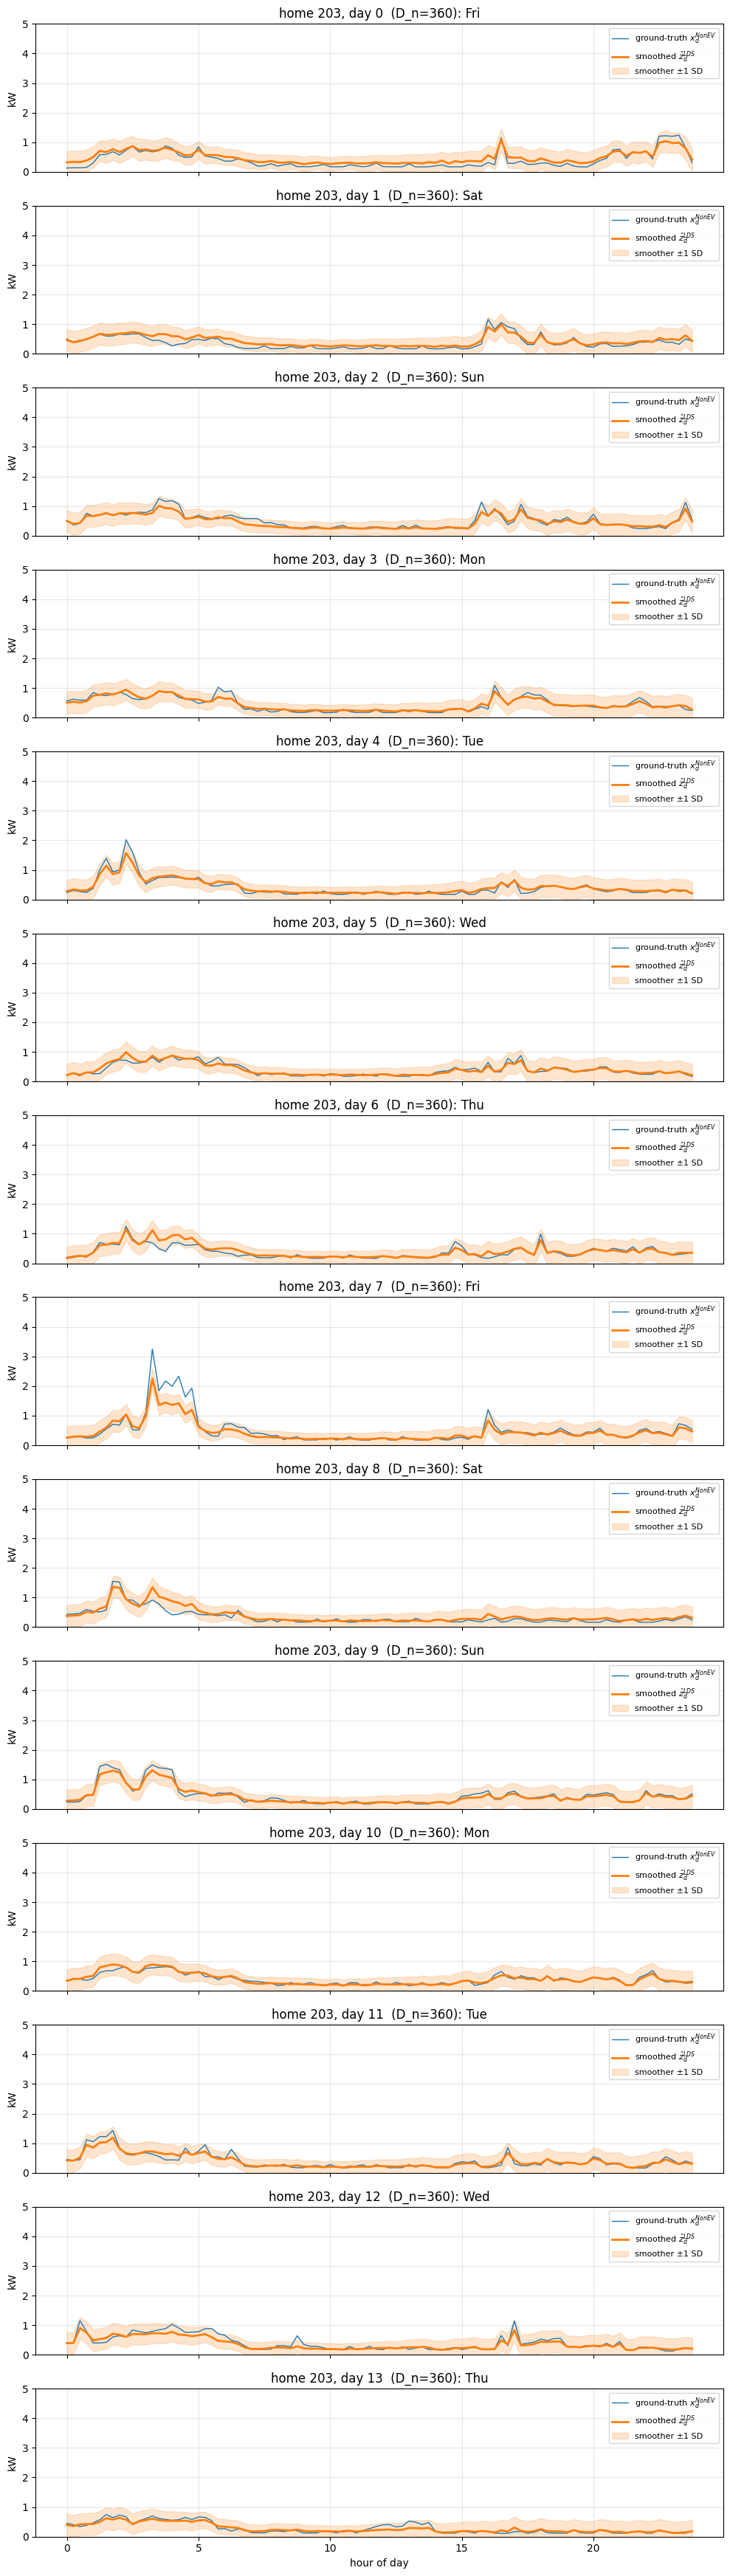

In [68]:
day_of_week_strings = [
    'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'
]


# Cache the smoother per home (one smoother call covers all that home's days).
smoothed_cache = {}
for hid, _ in pairs_to_plot:
    if hid not in smoothed_cache:
        smoothed_cache[hid] = lds.smooth(home_to_nonev[hid])

tt = np.arange(T) * 15 / 60   # hours of day
n  = len(pairs_to_plot)
fig, axes = plt.subplots(n, 1, figsize=(10, 2.5 * n), sharex=True)
if n == 1:
    axes = [axes]

for (hid, d), ax in zip(pairs_to_plot, axes):
    x_nev   = home_to_nonev[hid]
    sm      = smoothed_cache[hid]
    z_d     = sm.z_smooth[d]                          # (T,)
    z_d_sd  = np.sqrt(np.diag(sm.P_smooth[d]))        # (T,)
    truth   = x_nev[d]

    ax.plot(tt, truth, lw=1.0, color='C0', label=r'ground-truth $x^{NonEV}_d$')
    ax.plot(tt, z_d,   lw=2.0, color='C1', label=r'smoothed $\hat z^{LDS}_d$')
    ax.fill_between(tt, z_d - z_d_sd, z_d + z_d_sd, color='C1', alpha=0.2,
                    label='smoother ±1 SD')

    ax.set_title(f'home {hid}, day {d}  (D_n={x_nev.shape[0]}): {day_of_week_strings[home_to_day_of_week[hid][d]]}')
    ax.set_ylabel('kW')

    ax.set_ylim(0, 5)

    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('hour of day')
plt.tight_layout(); plt.show()

## 4. Per-home marginal $\log p(x^{NonEV})$

Higher per-day log p ⇒ the LDS thinks this home's Non-EV time series is
well-explained by the fitted parameters. Use the spread to spot outlier
homes the LDS fits poorly.

In [69]:
ll_per_home_per_day = {}
ll_total = 0.0; D_total = 0
for hid, x in home_to_nonev.items():
    ll = lds.loglik(x)
    ll_per_home_per_day[hid] = ll / x.shape[0]
    ll_total += ll
    D_total  += x.shape[0]

vals = np.array(list(ll_per_home_per_day.values()))
print(f'Total log p(x^NonEV)         = {ll_total:+.1f}  (over {D_total} home-days)')
print(f'Mean per-(home,day) log p    = {ll_total / D_total:+.3f}')
print(f'Per-(home,day) log p stats: '
      f'min={vals.min():+.2f}, median={np.median(vals):+.2f}, max={vals.max():+.2f}')
print()

shown_homes = sorted(set(hid for hid, _ in pairs_to_plot))
print('For the plotted homes:')
for hid in shown_homes:
    print(f'  home {hid:>6}  per-day logL = {ll_per_home_per_day[hid]:+.3f}')

Total log p(x^NonEV)         = -1979184.1  (over 16082 home-days)
Mean per-(home,day) log p    = -123.068
Per-(home,day) log p stats: min=-397.12, median=-106.39, max=-68.88

For the plotted homes:
  home    203  per-day logL = -86.087


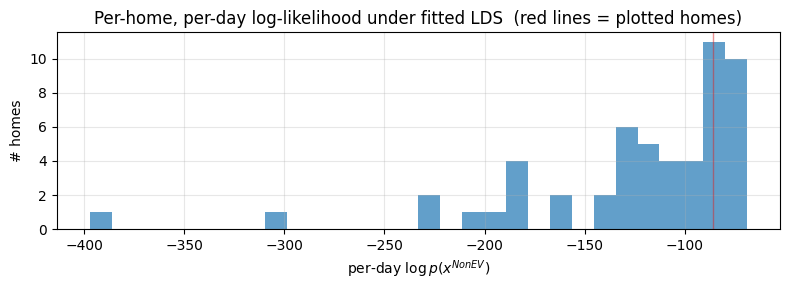

In [70]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(vals, bins=30, color='C0', alpha=0.7)
for hid in shown_homes:
    ax.axvline(ll_per_home_per_day[hid], color='C3', alpha=0.5, lw=1)
ax.set_xlabel(r'per-day $\log p(x^{NonEV})$'); ax.set_ylabel('# homes')
ax.set_title('Per-home, per-day log-likelihood under fitted LDS  '
             '(red lines = plotted homes)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()